In [3]:
from subprocess import getoutput
import os
import cantera as ct
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import re
import csv
from scipy.interpolate import interp1d
import json
import copy

%matplotlib inline

In [17]:
def convert_to_yaml(chemkin_number): 
    output = getoutput(f'ck2yaml --input=chem0{chemkin_number}.inp --transport=tran.dat')
    print(output)
    
    #manually add in 'explicit-third-body-duplicates: mark-duplicate' flag
    with open(f'./chem0{chemkin_number}.yaml', 'r') as f:
        lines = f.readlines()
        
    edited_yaml_lines = []
    for line in lines: 
        edited_yaml_lines.append(line) 
        if '- name: gas' in line: 
            edited_yaml_lines.append('  explicit-third-body-duplicates: mark-duplicate\n') #add in the flag
        
            
    with open(f'./chem0{chemkin_number}.yaml', 'w') as f:
        f.writelines(edited_yaml_lines)
    

In [5]:
os.chdir('./chemkin')

In [23]:
chemkins_to_convert = list(range(225, 230)) + list(range(255, 260))
print(chemkins_to_convert)

[225, 226, 227, 228, 229, 255, 256, 257, 258, 259]


In [24]:
#chemkins_to_convert = list(range(225, 233))
chemkins_to_convert = list(range(225, 230)) + list(range(255, 260))
for cn in chemkins_to_convert: 
    convert_to_yaml(cn)

Wrote YAML mechanism file to 'chem0225.yaml'.
Mechanism contains 225 species and 1351 reactions.
Validating mechanism...
FAILED
Undeclared duplicate reaction H2(22) + M <=> H(13) + H(13) + M
found on lines 3004 and 3291 of the kinetics input file.
Wrote YAML mechanism file to 'chem0226.yaml'.
Mechanism contains 226 species and 1365 reactions.
Validating mechanism...
FAILED
Undeclared duplicate reaction H2(22) + M <=> H(13) + H(13) + M
found on lines 3010 and 3297 of the kinetics input file.
Wrote YAML mechanism file to 'chem0227.yaml'.
Mechanism contains 227 species and 1372 reactions.
Validating mechanism...
FAILED
Undeclared duplicate reaction H2(22) + M <=> H(13) + H(13) + M
found on lines 3016 and 3303 of the kinetics input file.
Wrote YAML mechanism file to 'chem0228.yaml'.
Mechanism contains 228 species and 1377 reactions.
Validating mechanism...
FAILED
Undeclared duplicate reaction H2(22) + M <=> H(13) + H(13) + M
found on lines 3022 and 3309 of the kinetics input file.
Wrote YA

TEMP  ACTUAL TEMP IN CENTER  Difference
800 	 712.6824333155304 	 87.31756668446963
850 	 770.015506327582 	 79.98449367241801
900 	 823.3927715664618 	 76.60722843353824
950 	 874.795037329749 	 75.204962670251
1000 	 940.0339170661575 	 59.96608293384247
1050 	 1001.3189253033898 	 48.68107469661015
1100 	 1025.0421542984475 	 74.95784570155251
Customizing profiles for 400-750 with average peak temperature difference of 71.81703639895457 deg C.



Calculated maximum value for 400: 328.72, should be close to 328.18296360104546
Calculated maximum value for 450: 378.18, should be close to 378.18296360104546
Calculated maximum value for 500: 428.18, should be close to 428.18296360104546
Calculated maximum value for 550: 478.18, should be close to 478.18296360104546
Calculated maximum value for 600: 528.18, should be close to 528.1829636010455
Calculated maximum value for 650: 578.19, should be close to 578.1829636010455
Calculated maximum value for 700: 628.18, should be close to 628.182

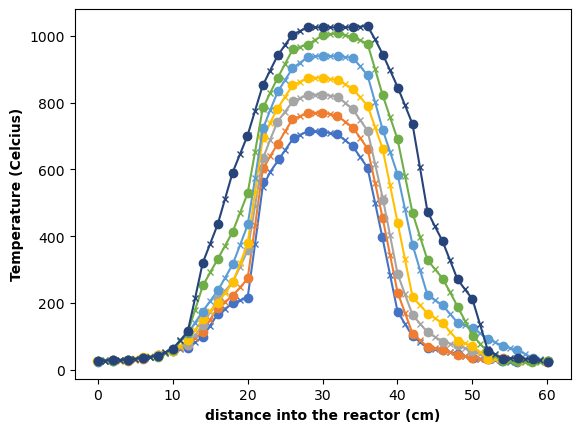

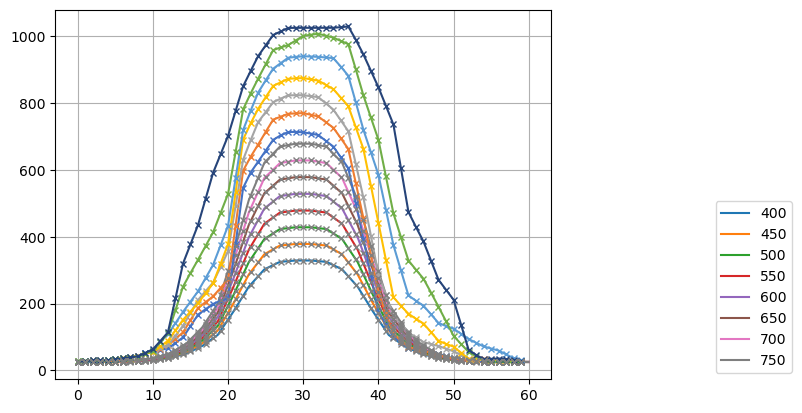

In [7]:
def convert_to_Kelvin(temp_C): 
    temp_K = temp_C + 273.15 
    return temp_K

def run_edited_mech_sim(temp, mech_path, Weber=False, calculate_sensitivities=False, edit_gas_in_cantera=False):
    """pass in a mechanism path (usual a mechanism that is slightly edited) and run the COR simulation on it."""
    
    z_data = np.linspace(0,60,500)
    
    gas_full=ct.Solution(mech_path)

    if edit_gas_in_cantera==True: 
        #edit the gas so it does not include reactions with CF3O(73)
        all_species = gas_full.species()
        species = []
        for S in all_species: 

            # if S.name in ['HO2(32)']:
            #     comp = S.composition
            #     if comp['H']==1 and comp['O']==2: 
            #         print('excluding HO2')
            #         continue #skipping this one
            species.append(S)
        species_names = {S.name for S in species}


        all_reactions = gas_full.reactions()
        print(f'Gas (full) previously had {len(all_reactions)} reactions.')
        reactions = []

        for R in all_reactions:
            add_in=True
#         for side in [R.reactants, R.products]:  
#             if len(side)==2: 
#                 if 'O2(2)' in side: 
#                     shouldnt_have = ['C4F9(291)', 'C5F11(293)', 'C6F13', 'C7F15(301)']
#                     if any([spec in shouldnt_have for spec in side if spec!='O2(2)']):
#                         print(f'Excluding {str(R)}')
#                         add_in=False
        
        
            spec_of_interest = ['C8H2F15O2(338)', 'C8H2F15O2(1016)', 'C8H2F15O2(339)', 'C8F14O2(371)', 'C7F14O(529)']

            #should_have = ['CO(8)', 'C6F13']
            # if all(spec in R.equation for spec in spec_of_interest):
            if any(spec in R.equation for spec in spec_of_interest):
                print(f'excluding {str(R.equation)}')
                add_in=False

                #if any((len(side)==1 and spec_of_interest[0] in list(side.keys())[0]) for side in [rxn.reactants, rxn.products]): 
                # else: 
                #     print(f'excluding {str(R.equation)}')
                #     add_in=False
            remove_this_pdep_network =  ['O2(413)', 'C2F4(5)']
            if all(spec in R.equation for spec in remove_this_pdep_network): 
                for side in [R.reactants, R.products]: 
                    if all(spec in side for spec in remove_this_pdep_network): 
                        #this is likely the pdep network that's reacting these two
                        print(f'PDEP excluding {str(R.equation)}')
                        add_in=False
                        

            if add_in==True: 
                reactions.append(R)

        
        print(f'Gas (small) now has {len(reactions)} reactions.')

        gas_small = ct.Solution(thermo='IdealGas', kinetics='GasKinetics',
                           species=species, reactions=reactions)
        print('using gas small')
        gas = gas_small
    
    
    if edit_gas_in_cantera==False: 
    
        print('using gas full')
        gas = gas_full
    
    
    
    if Weber:    
        initial_composition ={"PFOA": 4.02e-4, #402 ppm of PFOA,
                            "H2O": 7.50e-4, #750 ppm of H2O(g) 
                            "O2": 0.20975808, #Total of trace species: 4.02e-4 + 7.50e-4 = 1.152e-3, Remaining fraction for air: 1 - 1.152e-3 = 0.998848, 21% O2, 79% N2
                            "N2": 0.78908992,
                            }
        
    else: 
        initial_composition ={"PFOA(1)": 4.02e-4, #402 ppm of PFOA,
                            "H2O(3)": 7.50e-4, #750 ppm of H2O(g) 
                            "O2(2)": 0.20975808, #Total of trace species: 4.02e-4 + 7.50e-4 = 1.152e-3, Remaining fraction for air: 1 - 1.152e-3 = 0.998848, 21% O2, 79% N2
                            "N2": 0.78908992,
                            }


    print('using master_temp_dict')
    T_profile = master_temp_dict[temp][2]

    
    
    gas.TPX = 300, ct.one_atm, initial_composition
    
    int_diam = 0.007 #in meters, experiments have a 7 mm ID in reactor
    radius = int_diam/2
    cross_area = np.pi*radius*radius #cross sectional area [m**2]
    Vdot = 150e-6 / 60.0 #volumetric flow rate, 150 mL/min → m³/s
    v0 = Vdot/cross_area #m/s, velocity in x direction 
    length = 0.6 #in m, 60 cms
    

    n_steps = len(z_data)
    dz = length / n_steps
        
    states = ct.SolutionArray(gas, extra=['z', 'time', 'temp']) #for storing state information as we march through the reactor
    
    sensitivity_data = []        
    time = 0 
    for i, z in enumerate(z_data):
        
        T_C = float(T_profile(z))
        T_K = convert_to_Kelvin(T_C)
        

        gas.TP = T_K, ct.one_atm
        tau = dz / v0  # residence time in this slice
        #r = ct.IdealGasConstPressureReactor(gas, energy='off')  #'off' = fixed T, because we are manually enforcing T
        r = ct.IdealGasReactor(gas, energy='off')  #'off' = fixed T, because we are manually enforcing T
        sim = ct.ReactorNet([r])

        if calculate_sensitivities==True: 
                if z==z_data[-1]: #if we're on the last dz 
                    for i in range(gas.n_reactions):
                        r.add_sensitivity_reaction(i) #enable sensitivity with respect to the rates
                        # set the tolerances for the solution and for the sensitivity coefficients
                    #print('finished adding sensitivities')
                    sim.rtol = 1.0e-6
                    sim.atol = 1.0e-15
                    sim.rtol_sensitivity = 1.0e-6
                    sim.atol_sensitivity = 1.0e-6
            
        try:
            time+=tau
            sim.advance(tau)
            if calculate_sensitivities==True:
                if z==z_data[-1]: #if we're on the last dz 
                    for i in range(gas.n_reactions):
                        sensitivity_to_HF = sim.sensitivity('HF(4)', i) #sensitivity of HF to reaction i 
                        reaction_for_sens = gas.reactions()[i]
                        sensitivity_data.append(sensitivity_to_HF, reaction_for_sens.equation)
                        
                        
        except Exception as e:
            print(f"\nIntegration failed at z={z:.3f} m, T={T_K:.1f} K")
            print(f"Species with non-finite values: "
                  f"{[s for s, X in zip(gas.species_names, r.thermo.X) if not np.isfinite(X)]}")
            raise e
 
        
        states.append(r.thermo.state, z=z, time=time, temp=gas.T)
        gas.X = r.thermo.X # propagate composition only
    return states, gas, sensitivity_data 


def simulate_one_point(path_to_model, species_to_look_for): 
    
    master_dictionary_for_concentrations={}
                      
    species_to_plot = [
                       'HF(4)', #HF
                       'C2F4(5)', #C2F4
                        'CO2(6)', #CO2
                        'C2F6(7)',   #C2F6, 
                        'CO(8)', #CO
                        'CF4(9)', #CF4
                        'COF2(10)',  #COF2
                      ]   
                      
    only_interested_in = [
        spc for spc in species_to_plot
        if any(f"{interested_spec}(" in spc for interested_spec in species_to_look_for)
    ]    
    

    temps_of_interest = {'HF(4)': 850, 
                        'C2F4(5)': 700,
                        'CO2(6)': 800, 
                        'C2F6(7)': 850,   
                        'CO(8)': 750, 
                        'CF4(9)': 900, 
                        'COF2(10)': 800,
                        }



    all_temperatures = range(600, 1150, 50)

    for temp in all_temperatures: 

       
        simulate_flag = False 

        #do we want to simulate at this temperature?
        for spec_of_interest in only_interested_in: 
            if temp == temps_of_interest[spec_of_interest]:
                simulate_flag=True #don't change 
            

        if simulate_flag == True: 

            try:
                print(f'Simulating for temperature {temp}')
                states1, gas1, sensitivity_data1 = run_edited_mech_sim(temp, path_to_model, Weber=False, calculate_sensitivities=False, edit_gas_in_cantera=False)


            except ct.CanteraError as e: 
                print(e)
                print(f'skipping {temp}, difficulty simulating.')
                continue

            for spec_of_interest in only_interested_in:    
                
                if temp == temps_of_interest[spec_of_interest]: 
                    
                    print(spec_of_interest)
                      
                    PFOA_concentration_1 = states1.concentrations[:, gas1.species_index('PFOA(1)')]
                    species_of_interest_concentration_1 = states1.concentrations[:, gas1.species_index(spec_of_interest)]
                    exit_concentration_1 = species_of_interest_concentration_1[-1]/PFOA_concentration_1[0]  
                    
                    master_dictionary_for_concentrations[spec_of_interest] = [temp, exit_concentration_1]
    print('FINISHED CALCULATIONS')  
    return master_dictionary_for_concentrations


temperature_profiles = pd.read_csv('/projects/westgroup/nora/Code/projects/rebasing_PFAS/models/PFAS/insights_from_Weber/PFOA+Air/temperature_profiles_from_literature.csv')

temperatures = range(800,1150, 50)
master_temp_dict = {}

#start plotting
fig = plt.figure()
ax1 = fig.add_subplot(111)


rbg_colors = {800: (68, 114, 196), 
              850: (238, 125, 49), 
              900: (165, 165, 165), 
              950: (255, 192, 2), 
              1000: (91, 156, 213), 
              1050: (112, 174, 71), 
              1100: (38, 68, 121)}
    
for temp in temperatures:
    
    index_of_x = temperature_profiles.columns.get_loc(str(temp))
    index_of_y = index_of_x+1 
    
    distances_str = temperature_profiles.iloc[:, index_of_x]
    distances = [float(x) for x in distances_str[1:]]
    
    temperatures_at_distances_str = temperature_profiles.iloc[:, index_of_y]
    temperatures_at_distances = [float(x) for x in temperatures_at_distances_str[1:]]
        
    colors = tuple([color_num/255 for color_num in rbg_colors[temp]])
    
    ax1.plot(distances, temperatures_at_distances,'o',c=colors)
    
    
    #create an interpolation function 
    T_profile = interp1d(distances, temperatures_at_distances, kind='linear', fill_value='extrapolate')
    more_points_distances = range(0, 60, 1)
    ax1.plot(more_points_distances, [T_profile(z) for z in more_points_distances],'x-',c=colors, markersize=5, label=f"corrections to ABL, no branching")

   #append to master dictionary so we can use this is PFR sims
    master_temp_dict[temp] = [distances, temperatures_at_distances, T_profile]
    
plt.xlabel('distance into the reactor (cm)',fontweight='bold')
plt.ylabel('Temperature (Celcius)',fontweight='bold')

# customized temperature profile for 400 - 750 degrees C 
print('TEMP  ACTUAL TEMP IN CENTER  Difference')
temp_differences_at_peak = []

for temp in temperatures:
    
    index_of_x = temperature_profiles.columns.get_loc(str(temp))
    index_of_y = index_of_x+1 
    
    distances_str = temperature_profiles.iloc[:, index_of_x]
    distances = [float(x) for x in distances_str[1:]]
    
    temperatures_at_distances_str = temperature_profiles.iloc[:, index_of_y]
    temperatures_at_distances = [float(x) for x in temperatures_at_distances_str[1:]]
        
    
    #find the index of the distances that is closes to 30 
    difference_from_30 = [abs(30-x) for x in distances]
    closest_to_30 = min(difference_from_30)
    index_for_center_of_reactor = difference_from_30.index(closest_to_30)

    print(temp, '\t', temperatures_at_distances[index_for_center_of_reactor], '\t', temp-temperatures_at_distances[index_for_center_of_reactor])
    temp_differences_at_peak.append(temp-temperatures_at_distances[index_for_center_of_reactor])

average_difference = np.average(temp_differences_at_peak)
print(f'Customizing profiles for 400-750 with average peak temperature difference of {average_difference} deg C.\n\n\n')

def custom_gaussian(x, min_val, max_val, mean, std_dev):
    """
    Generates a Gaussian function with specified minimum and maximum values.

    Args:
        x (numpy.ndarray or float): The input value(s).
        min_val (float): The minimum value (offset) of the function.
        max_val (float): The desired maximum value of the function.
        mean (float): The mean (center) of the Gaussian peak.
        std_dev (float): The standard deviation (width) of the Gaussian.

    Returns:
        numpy.ndarray or float: The calculated Gaussian value(s).
    """
    amplitude = max_val - min_val
    # The standard Gaussian formula
    y = amplitude * np.exp(-(x - mean)**2 / (2 * std_dev**2)) + min_val
    return y

#start plotting the whole thing
fig = plt.figure()
ax1 = fig.add_subplot(111)


manual_adjustments = {400: 89,
450: 478.37 - 378.18296360104546,
500: 539.01 - 428.18296360104546,
550: 599.66 - 478.18296360104546,
600: 660.30 - 528.1829636010455,
650: 720.94 - 578.1829636010455,
700: 781.59 - 628.1829636010455,
750: 842.23 - 678.1829636010455,
                     }
                      
temperatures_to_customize = range(400,800,50)
for cust_temp in temperatures_to_customize: 
    
    ##### get custom temperature profile edges (distances 0-25, 35-60)
 
    # Parameters
    min_val = 25 #deg C
    max_val = cust_temp - average_difference #always a little lower than desired temperature
    mean = 30 #cm
    std_dev = 7

    # Generate x values
    x_values = np.linspace(0, 60, 30) # Range from -4*sigma to 4*sigma covers most of the curve

    # Calculate the corresponding y values
    y_values_edges = custom_gaussian(x_values, min_val, max_val, mean, std_dev)
    T_profile_edges = interp1d(x_values, y_values_edges, kind='linear', fill_value='extrapolate')

    
    ##### get custom temperature profile for middle (distances 25-35)
    # Parameters
    mean_1, mean_2 = 25, 35 #cm
    std_dev = 5


    # Calculate the corresponding y values
    y_values_1 = custom_gaussian(x_values, min_val, max_val, mean_1, std_dev)
    y_values_2 = custom_gaussian(x_values, min_val, max_val, mean_2, std_dev)
    
    T_profile_1 = interp1d(x_values, y_values_1, kind='linear', fill_value='extrapolate')
    T_profile_2 = interp1d(x_values, y_values_2, kind='linear', fill_value='extrapolate')



    ######### put the y values together and run through the interpolate function to get final temperature profile 
    desired_y_values = []
    for x in x_values: 
        if x<20: 
            y = T_profile_edges(x)
        if x>=20 and x<=40: 
            y = T_profile_1(x) + T_profile_2(x) - manual_adjustments[cust_temp] #drop middle section down so it connects to edges
        if x>40: 
            y = T_profile_edges(x)
        desired_y_values.append(y)
        
    final_T_profile = interp1d(x_values, desired_y_values, kind='linear', fill_value='extrapolate')

    
    
    ax1.plot(x_values, [final_T_profile(x) for x in x_values], label=f'{cust_temp}')

    
    
    
    # Verify the min and max values (should be close to the defined parameters)
    print(f"Calculated maximum value for {cust_temp}: {np.max([final_T_profile(x) for x in x_values]):.2f}, should be close to {max_val}")

    
    #overwrite with new custom temp profiles 
    master_temp_dict[cust_temp] = [x_values, [final_T_profile(x) for x in x_values], final_T_profile]
    
    
rbg_colors = {800: (68, 114, 196), 
              850: (238, 125, 49), 
              900: (165, 165, 165), 
              950: (255, 192, 2), 
              1000: (91, 156, 213), 
              1050: (112, 174, 71), 
              1100: (38, 68, 121)}
    
for temp, [distances, temperatures_at_distances, T_profile] in master_temp_dict.items():

    #create an interpolation function 
    more_points_distances = range(0, 60, 1)
    
    #800 - 1100 K
    if temp in rbg_colors.keys():
        colors = tuple([color_num/255 for color_num in rbg_colors[temp]])
        ax1.plot(more_points_distances, [T_profile(z) for z in more_points_distances],'x-',c=colors, markersize=5,)
        
    else: 
        ax1.plot(more_points_distances, [T_profile(z) for z in more_points_distances],'x', c='gray', markersize=5,)


plt.grid(True)
plt.legend(bbox_to_anchor=(1.5,0.5))

In [11]:
chemkins_to_convert = list(range(200, 261, 5))
print(chemkins_to_convert)

[200, 205, 210, 215, 220, 225, 230, 235, 240, 245, 250, 255, 260]


---------------225--------------
Simulating for temperature 750
using gas full
using master_temp_dict


/tmp/ipykernel_1620572/1038187503.py:128: DeprecationWarning: ReactorBase.__init__: After Cantera 3.2, the default value of the `clone` argument will be `True`, resulting in an independent copy of the `phase` being created for use by this reactor. Add the `clone=False` argument to retain the old behavior of sharing `Solution` objects.
  r = ct.IdealGasReactor(gas, energy='off')  #'off' = fixed T, because we are manually enforcing T
/tmp/ipykernel_1620572/1038187503.py:160: DeprecationWarning: ReactorBase.thermo: To be removed after Cantera 3.2. Renamed to `phase`.
  states.append(r.thermo.state, z=z, time=time, temp=gas.T)
/tmp/ipykernel_1620572/1038187503.py:161: DeprecationWarning: ReactorBase.thermo: To be removed after Cantera 3.2. Renamed to `phase`.
  gas.X = r.thermo.X # propagate composition only


CO(8)
Simulating for temperature 850
using gas full
using master_temp_dict
C2F6(7)
FINISHED CALCULATIONS
850 0.188765050981523
750 2.52025115548983e-05
---------------226--------------
Simulating for temperature 750
using gas full
using master_temp_dict

Integration failed at z=59.519 m, T=298.3 K
Species with non-finite values: []

*******************************************************************************
CanteraError thrown by CVodesIntegrator::integrate:
CVodes error encountered. Error code: -3
cvHandleFailure: At t = 3.19077391968003e-05 and h = 1.21868198099391e-11, the error test failed repeatedly or with |h| = hmin.

Components with largest weighted error estimates:
16: 59.9261134553537
12: -52.9684114208037
30: 32.44294116984834
8: -0.07236290494213064
82: 1.2286591109937947e-07
20: 4.3280335343979066e-08
29: 1.0414399157504865e-08
104: 8.143402453796748e-09
130: -6.168420519094671e-09
125: -6.0515267732852905e-09
***********************************************************

/tmp/ipykernel_1620572/1038187503.py:156: DeprecationWarning: ReactorBase.thermo: To be removed after Cantera 3.2. Renamed to `phase`.
  f"{[s for s, X in zip(gas.species_names, r.thermo.X) if not np.isfinite(X)]}")


using gas full
using master_temp_dict

Integration failed at z=48.938 m, T=313.7 K
Species with non-finite values: []

*******************************************************************************
CanteraError thrown by CVodesIntegrator::integrate:
CVodes error encountered. Error code: -3
cvHandleFailure: At t = 0.000121071474134348 and h = 1.94985054304166e-11, the error test failed repeatedly or with |h| = hmin.

Components with largest weighted error estimates:
16: 101.51302847511809
30: 72.48451906472793
12: -47.38699434304759
8: -0.17600120961262058
220: -4.0352357008545455e-06
226: 1.8936917735894912e-06
94: -1.8891783033261325e-06
28: 1.214333286779349e-07
130: -2.12621416184008e-08
71: 1.708605750902514e-08
*******************************************************************************

skipping 850 CO(8)
FINISHED CALCULATIONS
---------------227--------------
Simulating for temperature 750
using gas full
using master_temp_dict
CO(8)
Simulating for temperature 850
using gas fu

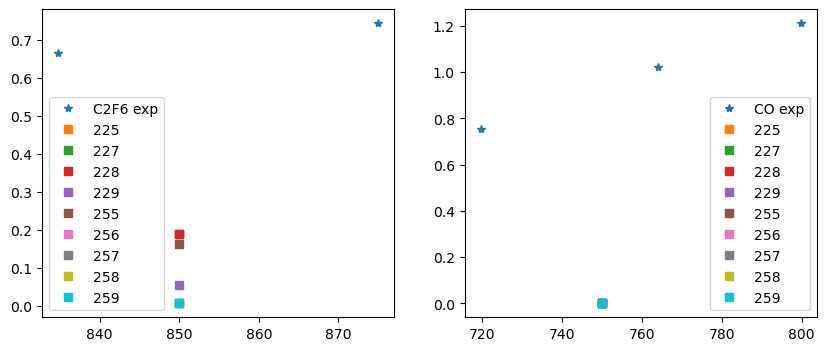

In [25]:
chemkins_to_convert = list(range(225, 230)) + list(range(255, 260))
# chemkins_to_convert = [23
species_to_look_at = ['C2F6', 'CO']

exp_mapping = {'HF(4)': 'HF', 
               'C2F4(5)': 'C2F4', 
               'CO2(6)': 'CO2', 
               'C2F6(7)': 'C2F6', 
               'CO(8)': 'CO', 
               'CF4(9)': 'CF4', 
               'COF2(10)': 'COF2'} 

inverted_dict = {value: key for key, value in exp_mapping.items()}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4)) # 1 row, 2 columns

#C2F6 exp
c2f6_exp_temps = [834.7643979057591, 874.9738219895288]
c2f6_conc_ratio = [0.665474060822898, 0.7441860465116279]
ax1.plot(c2f6_exp_temps, c2f6_conc_ratio, '*', label='C2F6 exp') #C2F6


#CO exp
co_exp_temps = [719.6083208613228, 764.1455802675391, 799.7795644657919]
co_conc_ratio = [0.7522768670309654, 1.0200364298724955, 1.2112932604735884]
ax2.plot(co_exp_temps, co_conc_ratio, '*', label='CO exp') #CO


for cn in chemkins_to_convert:
    print(f'---------------{cn}--------------')
    if cn=='228':
        continue
    path_to_model = f'/projects/westgroup/nora/Code/projects/rebasing_PFAS/models/PFAS/insights_from_Weber/PFOA+Air/fix_reg_spec_in_core/lower_tolerance/ANL_Brown_smc_RAMB_as_lib/all_non_pdep_as_lib/pdep_dup_fix/auto_True_1+2Cyclo/new_completed_network/chemkin/chem0{cn}.yaml'
    master_dictionary_for_concentrations = simulate_one_point(path_to_model, species_to_look_at)
    for spc in species_to_look_at: 
        try: 
            [temp, exit_concentration_1] = master_dictionary_for_concentrations[inverted_dict[spc]]
            print(temp, exit_concentration_1)
            if spc=='C2F6':
                ax1.plot(temp, exit_concentration_1, 's', label=cn)
            if spc=='CO':
                ax2.plot(temp, exit_concentration_1, 's', label=cn)
        except KeyError:
            continue
ax1.legend()
ax2.legend()